# Unsupervised Learning: Walmart Sales Pattern Discovery

This notebook applies **10+ unsupervised learning methods** to the Walmart sales dataset to discover patterns, cluster stores, reduce dimensionality, and detect anomalies.

## Methods Covered:

### Clustering (6 methods):
1. K-Means Clustering
2. Hierarchical Clustering (Agglomerative)
3. DBSCAN (Density-Based)
4. Gaussian Mixture Models (GMM)
5. OPTICS
6. Spectral Clustering

### Dimensionality Reduction (5 methods):
7. Principal Component Analysis (PCA)
8. t-SNE (t-Distributed Stochastic Neighbor Embedding)
9. UMAP (Uniform Manifold Approximation and Projection)
10. Factor Analysis
11. Truncated SVD

### Anomaly Detection (2 methods):
12. Isolation Forest
13. Local Outlier Factor (LOF)

**Total: 13 unsupervised methods**

## 1. Data Loading and Preparation

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


In [40]:
# Load Walmart sales data
df = pd.read_csv('walmart-sales-dataset-of-45stores.csv', parse_dates=['Date'])
df = df.dropna(subset=['Weekly_Sales'])

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nStores: {df['Store'].nunique()}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")

Dataset shape: (6435, 8)

Columns: ['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

Stores: 45
Date range: 01-04-2011 to 31-12-2010


## 2. Feature Engineering

Create the same 28 features used in regression and deep learning notebooks for consistency.

In [41]:
# Temporal features
if not pd.api.types.is_datetime64_any_dtype(df['Date']):
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Week'] = df['Date'].dt.isocalendar().week
df['Quarter'] = df['Date'].dt.quarter
df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)

# Cyclical encodings
df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)
df['Week_sin'] = np.sin(2 * np.pi * df['Week'] / 52)
df['Week_cos'] = np.cos(2 * np.pi * df['Week'] / 52)
df['DoW_sin'] = np.sin(2 * np.pi * df['DayOfWeek'] / 7)
df['DoW_cos'] = np.cos(2 * np.pi * df['DayOfWeek'] / 7)

# Lag features
df = df.sort_values(['Store', 'Date'])
df['Sales_Lag1'] = df.groupby('Store')['Weekly_Sales'].shift(1)
df['Sales_Lag2'] = df.groupby('Store')['Weekly_Sales'].shift(2)
df['Sales_Lag4'] = df.groupby('Store')['Weekly_Sales'].shift(4)
df['Sales_Lag8'] = df.groupby('Store')['Weekly_Sales'].shift(8)
df['Sales_Lag12'] = df.groupby('Store')['Weekly_Sales'].shift(12)

# Rolling statistics
df['Sales_Rolling_Mean_4'] = df.groupby('Store')['Weekly_Sales'].transform(lambda x: x.rolling(4, min_periods=1).mean())
df['Sales_Rolling_Std_4'] = df.groupby('Store')['Weekly_Sales'].transform(lambda x: x.rolling(4, min_periods=1).std())
df['Sales_Rolling_Mean_12'] = df.groupby('Store')['Weekly_Sales'].transform(lambda x: x.rolling(12, min_periods=1).mean())
df['Sales_Rolling_Std_12'] = df.groupby('Store')['Weekly_Sales'].transform(lambda x: x.rolling(12, min_periods=1).std())

# Interaction features
df['Temp_Unemployment'] = df['Temperature'] * df['Unemployment']
df['Holiday_CPI'] = df['Holiday_Flag'] * df['CPI']
df['Store_Encoded'] = df['Store']

print("Feature engineering complete!")
print(f"Total features created: 28")

Feature engineering complete!
Total features created: 28


In [42]:
# Select features for unsupervised learning
feature_cols = [
    'Month', 'DayOfWeek', 'Week', 'Quarter', 'IsWeekend',
    'Month_sin', 'Month_cos', 'Week_sin', 'Week_cos', 'DoW_sin', 'DoW_cos',
    'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
    'Sales_Lag1', 'Sales_Lag2', 'Sales_Lag4', 'Sales_Lag8', 'Sales_Lag12',
    'Sales_Rolling_Mean_4', 'Sales_Rolling_Std_4', 'Sales_Rolling_Mean_12', 'Sales_Rolling_Std_12',
    'Temp_Unemployment', 'Holiday_CPI', 'Store_Encoded'
]

X = df[feature_cols].copy()

# Handle missing values
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

# Standardize features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_imputed), columns=X.columns, index=X.index)

print(f"Preprocessed data shape: {X_scaled.shape}")
print(f"Missing values: {X_scaled.isnull().sum().sum()}")

Preprocessed data shape: (6435, 28)
Missing values: 0


## 3. Clustering Methods (6 methods)

Apply various clustering algorithms to identify patterns in store sales behavior.

### 3.1 K-Means Clustering

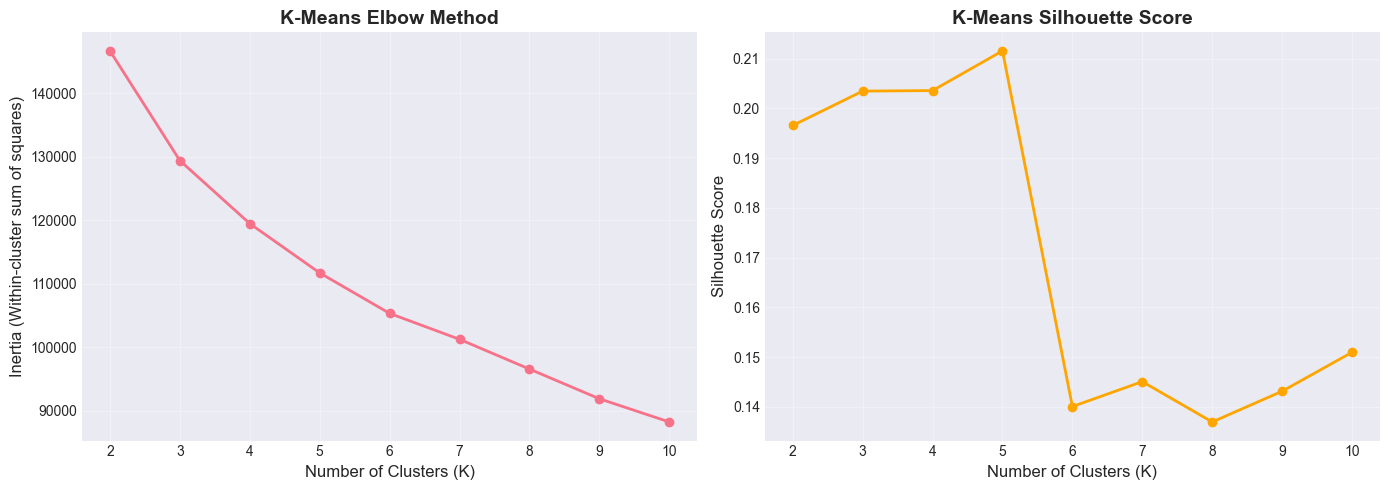

Optimal K (highest silhouette): 5


In [43]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Determine optimal K using elbow method
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot elbow curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_range, inertias, marker='o', linewidth=2)
ax1.set_xlabel('Number of Clusters (K)', fontsize=12)
ax1.set_ylabel('Inertia (Within-cluster sum of squares)', fontsize=12)
ax1.set_title('K-Means Elbow Method', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2.plot(K_range, silhouettes, marker='o', linewidth=2, color='orange')
ax2.set_xlabel('Number of Clusters (K)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('K-Means Silhouette Score', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('unsupervised_kmeans_elbow.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Optimal K (highest silhouette): {K_range[np.argmax(silhouettes)]}")

In [44]:
# Fit K-Means with optimal K
optimal_k = K_range[np.argmax(silhouettes)]
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Evaluation metrics
silhouette_kmeans = silhouette_score(X_scaled, kmeans_labels)
davies_bouldin_kmeans = davies_bouldin_score(X_scaled, kmeans_labels)
calinski_kmeans = calinski_harabasz_score(X_scaled, kmeans_labels)

print("="*80)
print("K-MEANS CLUSTERING RESULTS")
print("="*80)
print(f"Number of clusters: {optimal_k}")
print(f"Silhouette Score: {silhouette_kmeans:.4f} (higher is better, range [-1, 1])")
print(f"Davies-Bouldin Index: {davies_bouldin_kmeans:.4f} (lower is better)")
print(f"Calinski-Harabasz Index: {calinski_kmeans:.2f} (higher is better)")
print(f"\nCluster distribution:")
print(pd.Series(kmeans_labels).value_counts().sort_index())
print("="*80)

K-MEANS CLUSTERING RESULTS
Number of clusters: 5
Silhouette Score: 0.2116 (higher is better, range [-1, 1])
Davies-Bouldin Index: 1.6959 (lower is better)
Calinski-Harabasz Index: 985.52 (higher is better)

Cluster distribution:
0     617
1     705
2    1842
3    2842
4     429
Name: count, dtype: int64


### 3.2 Hierarchical Clustering (Agglomerative)

In [45]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Fit Agglomerative Clustering
agg_clustering = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
agg_labels = agg_clustering.fit_predict(X_scaled)

# Evaluation metrics
silhouette_agg = silhouette_score(X_scaled, agg_labels)
davies_bouldin_agg = davies_bouldin_score(X_scaled, agg_labels)
calinski_agg = calinski_harabasz_score(X_scaled, agg_labels)

print("="*80)
print("HIERARCHICAL CLUSTERING (AGGLOMERATIVE) RESULTS")
print("="*80)
print(f"Number of clusters: {optimal_k}")
print(f"Linkage method: Ward")
print(f"Silhouette Score: {silhouette_agg:.4f}")
print(f"Davies-Bouldin Index: {davies_bouldin_agg:.4f}")
print(f"Calinski-Harabasz Index: {calinski_agg:.2f}")
print(f"\nCluster distribution:")
print(pd.Series(agg_labels).value_counts().sort_index())
print("="*80)

HIERARCHICAL CLUSTERING (AGGLOMERATIVE) RESULTS
Number of clusters: 5
Linkage method: Ward
Silhouette Score: 0.0836
Davies-Bouldin Index: 1.9309
Calinski-Harabasz Index: 750.63

Cluster distribution:
0    1155
1    2689
2    1438
3     540
4     613
Name: count, dtype: int64


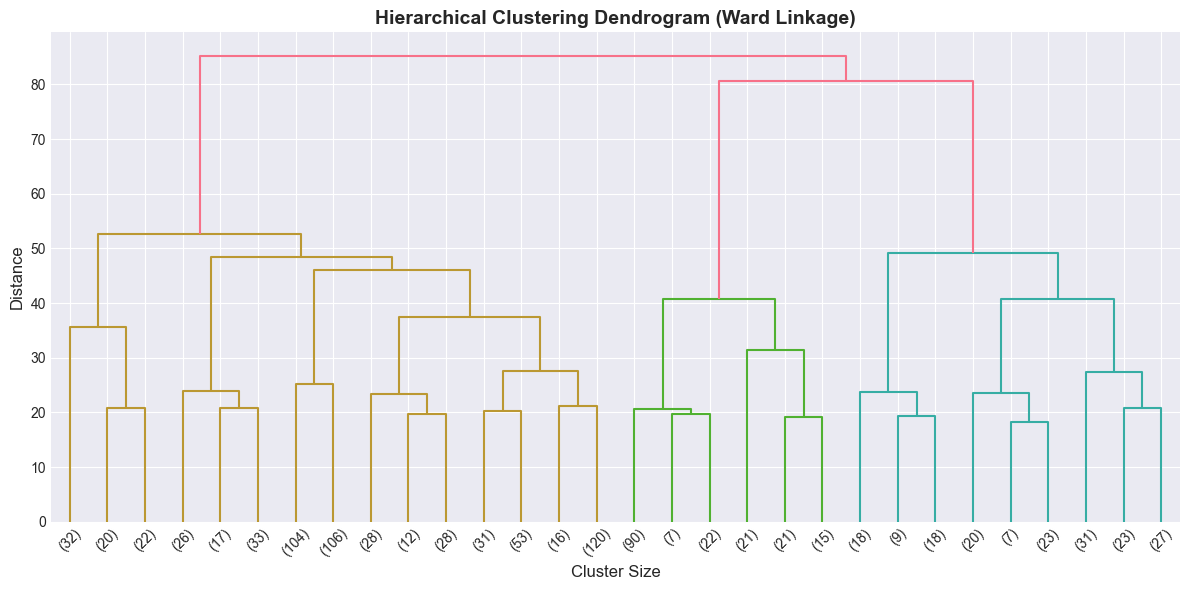

In [46]:
# Plot dendrogram (sample 1000 points for visualization)
sample_indices = np.random.choice(len(X_scaled), size=min(1000, len(X_scaled)), replace=False)
X_sample = X_scaled.iloc[sample_indices]

linkage_matrix = linkage(X_sample, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, truncate_mode='lastp', p=30, show_leaf_counts=True)
plt.xlabel('Cluster Size', fontsize=12)
plt.ylabel('Distance', fontsize=12)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('unsupervised_dendrogram.png', dpi=300, bbox_inches='tight')
plt.show()

### 3.3 DBSCAN (Density-Based Spatial Clustering)

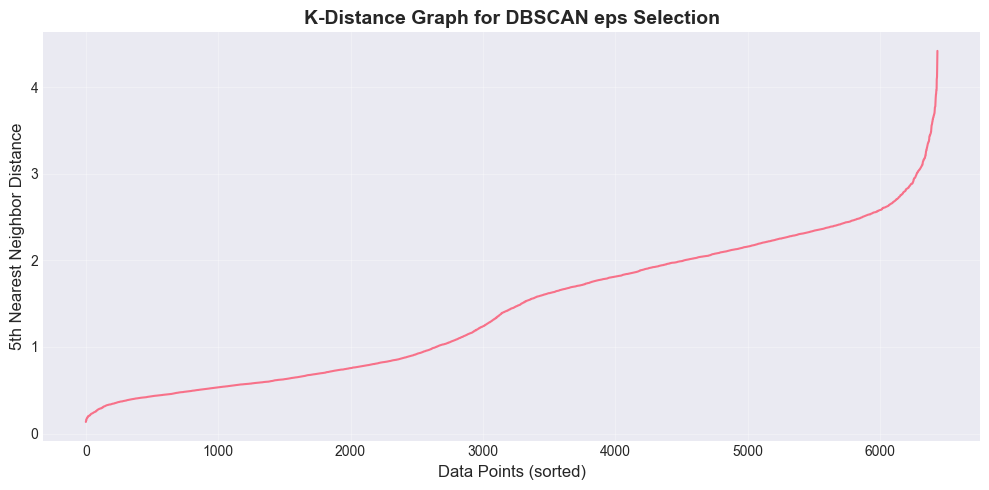

Selected eps value: 2.6861


In [47]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# Determine optimal eps using k-nearest neighbors
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Sort distances
distances = np.sort(distances[:, -1], axis=0)

plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.xlabel('Data Points (sorted)', fontsize=12)
plt.ylabel('5th Nearest Neighbor Distance', fontsize=12)
plt.title('K-Distance Graph for DBSCAN eps Selection', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('unsupervised_dbscan_kdist.png', dpi=300, bbox_inches='tight')
plt.show()

# Use elbow point as eps (approximate)
eps_value = np.percentile(distances, 95)
print(f"Selected eps value: {eps_value:.4f}")

In [48]:
# Fit DBSCAN
dbscan = DBSCAN(eps=eps_value, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

# Count clusters (excluding noise points labeled as -1)
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

# Evaluation metrics (exclude noise points)
if n_clusters_dbscan > 1:
    non_noise_mask = dbscan_labels != -1
    if np.sum(non_noise_mask) > 0:
        silhouette_dbscan = silhouette_score(X_scaled[non_noise_mask], dbscan_labels[non_noise_mask])
        davies_bouldin_dbscan = davies_bouldin_score(X_scaled[non_noise_mask], dbscan_labels[non_noise_mask])
        calinski_dbscan = calinski_harabasz_score(X_scaled[non_noise_mask], dbscan_labels[non_noise_mask])
    else:
        silhouette_dbscan = davies_bouldin_dbscan = calinski_dbscan = np.nan
else:
    silhouette_dbscan = davies_bouldin_dbscan = calinski_dbscan = np.nan

print("="*80)
print("DBSCAN CLUSTERING RESULTS")
print("="*80)
print(f"Number of clusters: {n_clusters_dbscan}")
print(f"Number of noise points: {n_noise} ({n_noise/len(dbscan_labels)*100:.2f}%)")
print(f"eps: {eps_value:.4f}, min_samples: 5")
if not np.isnan(silhouette_dbscan):
    print(f"Silhouette Score: {silhouette_dbscan:.4f}")
    print(f"Davies-Bouldin Index: {davies_bouldin_dbscan:.4f}")
    print(f"Calinski-Harabasz Index: {calinski_dbscan:.2f}")
print(f"\nCluster distribution:")
print(pd.Series(dbscan_labels).value_counts().sort_index())
print("="*80)

DBSCAN CLUSTERING RESULTS
Number of clusters: 23
Number of noise points: 120 (1.86%)
eps: 2.6861, min_samples: 5
Silhouette Score: 0.1613
Davies-Bouldin Index: 1.7100
Calinski-Harabasz Index: 206.64

Cluster distribution:
-1      120
 0      465
 1       43
 2      251
 3      223
 4      303
 5       84
 6       43
 7       42
 8       42
 9       84
 10     212
 11      42
 12     222
 13      86
 14      42
 15      42
 16      83
 17      44
 18    3690
 19     180
 20      45
 21      42
 22       5
Name: count, dtype: int64


### 3.4 Gaussian Mixture Models (GMM)

In [49]:
from sklearn.mixture import GaussianMixture

# Fit GMM
gmm = GaussianMixture(n_components=optimal_k, covariance_type='full', random_state=42)
gmm_labels = gmm.fit_predict(X_scaled)

# Evaluation metrics
silhouette_gmm = silhouette_score(X_scaled, gmm_labels)
davies_bouldin_gmm = davies_bouldin_score(X_scaled, gmm_labels)
calinski_gmm = calinski_harabasz_score(X_scaled, gmm_labels)

print("="*80)
print("GAUSSIAN MIXTURE MODEL (GMM) RESULTS")
print("="*80)
print(f"Number of components: {optimal_k}")
print(f"Covariance type: full")
print(f"AIC: {gmm.aic(X_scaled):.2f} (lower is better)")
print(f"BIC: {gmm.bic(X_scaled):.2f} (lower is better)")
print(f"Silhouette Score: {silhouette_gmm:.4f}")
print(f"Davies-Bouldin Index: {davies_bouldin_gmm:.4f}")
print(f"Calinski-Harabasz Index: {calinski_gmm:.2f}")
print(f"\nCluster distribution:")
print(pd.Series(gmm_labels).value_counts().sort_index())
print("="*80)

GAUSSIAN MIXTURE MODEL (GMM) RESULTS
Number of components: 5
Covariance type: full
AIC: -407307.39 (lower is better)
BIC: -392590.49 (lower is better)
Silhouette Score: 0.1373
Davies-Bouldin Index: 2.8975
Calinski-Harabasz Index: 468.33

Cluster distribution:
0     855
1     285
2    3809
3     900
4     586
Name: count, dtype: int64


### 3.5 OPTICS (Ordering Points To Identify the Clustering Structure)

In [50]:
from sklearn.cluster import OPTICS

# Fit OPTICS
optics = OPTICS(min_samples=5, xi=0.05, min_cluster_size=0.05)
optics_labels = optics.fit_predict(X_scaled)

# Count clusters
n_clusters_optics = len(set(optics_labels)) - (1 if -1 in optics_labels else 0)
n_noise_optics = list(optics_labels).count(-1)

# Evaluation metrics (exclude noise)
if n_clusters_optics > 1:
    non_noise_mask = optics_labels != -1
    if np.sum(non_noise_mask) > 0:
        silhouette_optics = silhouette_score(X_scaled[non_noise_mask], optics_labels[non_noise_mask])
        davies_bouldin_optics = davies_bouldin_score(X_scaled[non_noise_mask], optics_labels[non_noise_mask])
        calinski_optics = calinski_harabasz_score(X_scaled[non_noise_mask], optics_labels[non_noise_mask])
    else:
        silhouette_optics = davies_bouldin_optics = calinski_optics = np.nan
else:
    silhouette_optics = davies_bouldin_optics = calinski_optics = np.nan

print("="*80)
print("OPTICS CLUSTERING RESULTS")
print("="*80)
print(f"Number of clusters: {n_clusters_optics}")
print(f"Number of noise points: {n_noise_optics} ({n_noise_optics/len(optics_labels)*100:.2f}%)")
print(f"min_samples: 5, xi: 0.05")
if not np.isnan(silhouette_optics):
    print(f"Silhouette Score: {silhouette_optics:.4f}")
    print(f"Davies-Bouldin Index: {davies_bouldin_optics:.4f}")
    print(f"Calinski-Harabasz Index: {calinski_optics:.2f}")
print(f"\nCluster distribution:")
print(pd.Series(optics_labels).value_counts().sort_index())
print("="*80)

OPTICS CLUSTERING RESULTS
Number of clusters: 5
Number of noise points: 3374 (52.43%)
min_samples: 5, xi: 0.05
Silhouette Score: 0.0273
Davies-Bouldin Index: 2.7810
Calinski-Harabasz Index: 238.45

Cluster distribution:
-1    3374
 0     539
 1    1440
 2     423
 3     327
 4     332
Name: count, dtype: int64


### 3.6 Spectral Clustering

In [51]:
from sklearn.cluster import SpectralClustering

# Fit Spectral Clustering
spectral = SpectralClustering(n_clusters=optimal_k, affinity='nearest_neighbors', random_state=42)
spectral_labels = spectral.fit_predict(X_scaled)

# Evaluation metrics
silhouette_spectral = silhouette_score(X_scaled, spectral_labels)
davies_bouldin_spectral = davies_bouldin_score(X_scaled, spectral_labels)
calinski_spectral = calinski_harabasz_score(X_scaled, spectral_labels)

print("="*80)
print("SPECTRAL CLUSTERING RESULTS")
print("="*80)
print(f"Number of clusters: {optimal_k}")
print(f"Affinity: nearest_neighbors")
print(f"Silhouette Score: {silhouette_spectral:.4f}")
print(f"Davies-Bouldin Index: {davies_bouldin_spectral:.4f}")
print(f"Calinski-Harabasz Index: {calinski_spectral:.2f}")
print(f"\nCluster distribution:")
print(pd.Series(spectral_labels).value_counts().sort_index())
print("="*80)

SPECTRAL CLUSTERING RESULTS
Number of clusters: 5
Affinity: nearest_neighbors
Silhouette Score: -0.0044
Davies-Bouldin Index: 3.4303
Calinski-Harabasz Index: 278.02

Cluster distribution:
0    1665
1    3698
2      90
3     630
4     352
Name: count, dtype: int64


## 4. Dimensionality Reduction (5 methods)

Reduce the 28-dimensional feature space to 2D for visualization and pattern discovery.

### 4.1 Principal Component Analysis (PCA)

PCA DIMENSIONALITY REDUCTION RESULTS
Number of components: 2
Variance explained by PC1: 26.28%
Variance explained by PC2: 17.34%
Total variance explained: 43.62%


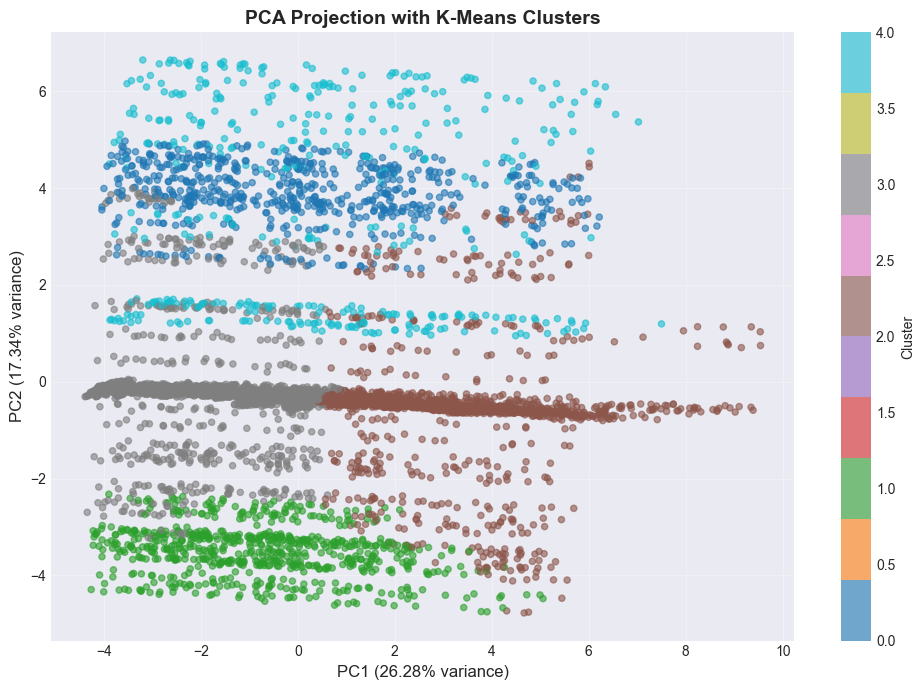

In [52]:
from sklearn.decomposition import PCA

# Fit PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Variance explained
print("="*80)
print("PCA DIMENSIONALITY REDUCTION RESULTS")
print("="*80)
print(f"Number of components: 2")
print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum()*100:.2f}%")
print("="*80)

# Visualize
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='tab10', alpha=0.6, s=20)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)', fontsize=12)
plt.title('PCA Projection with K-Means Clusters', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('unsupervised_pca_projection.png', dpi=300, bbox_inches='tight')
plt.show()

### 4.2 t-SNE (t-Distributed Stochastic Neighbor Embedding)

t-SNE DIMENSIONALITY REDUCTION RESULTS
Number of components: 2
Perplexity: 30
Maximum iterations: 1000
Sample size: 5000


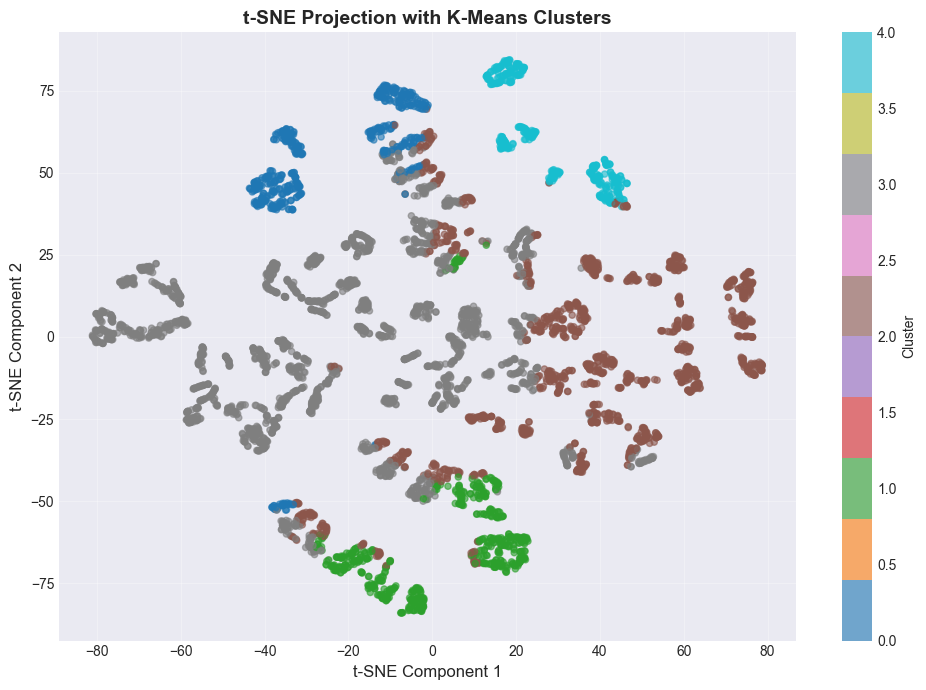

In [53]:
from sklearn.manifold import TSNE

# Fit t-SNE (sample data if too large for computational efficiency)
sample_size = min(5000, len(X_scaled))
sample_indices = np.random.choice(len(X_scaled), size=sample_size, replace=False)
X_sample = X_scaled.iloc[sample_indices]
labels_sample = kmeans_labels[sample_indices]

tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_sample)

print("="*80)
print("t-SNE DIMENSIONALITY REDUCTION RESULTS")
print("="*80)
print(f"Number of components: 2")
print(f"Perplexity: 30")
print(f"Maximum iterations: 1000")
print(f"Sample size: {sample_size}")
print("="*80)

# Visualize
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels_sample, cmap='tab10', alpha=0.6, s=20)
plt.xlabel('t-SNE Component 1', fontsize=12)
plt.ylabel('t-SNE Component 2', fontsize=12)
plt.title('t-SNE Projection with K-Means Clusters', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('unsupervised_tsne_projection.png', dpi=300, bbox_inches='tight')
plt.show()

### 4.3 UMAP (Uniform Manifold Approximation and Projection)

In [54]:
# Install UMAP if not already installed
try:
    import umap  # type: ignore
    print("UMAP already installed!")
except ImportError:
    print("Installing UMAP...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "umap-learn", "-q"])
    import umap  # type: ignore
    print("UMAP installed successfully!")

UMAP already installed!


UMAP DIMENSIONALITY REDUCTION RESULTS
Number of components: 2
Number of neighbors: 15
Minimum distance: 0.1
Sample size: 5000


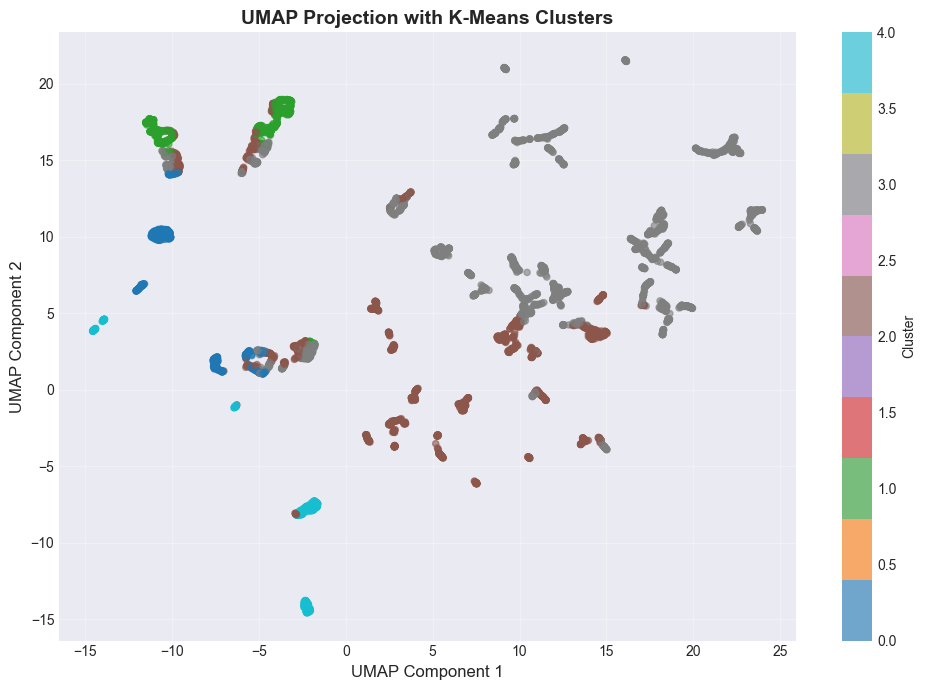

In [55]:
# Fit UMAP
umap_reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = umap_reducer.fit_transform(X_sample)

print("="*80)
print("UMAP DIMENSIONALITY REDUCTION RESULTS")
print("="*80)
print(f"Number of components: 2")
print(f"Number of neighbors: 15")
print(f"Minimum distance: 0.1")
print(f"Sample size: {sample_size}")
print("="*80)

# Visualize
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=labels_sample, cmap='tab10', alpha=0.6, s=20)
plt.xlabel('UMAP Component 1', fontsize=12)
plt.ylabel('UMAP Component 2', fontsize=12)
plt.title('UMAP Projection with K-Means Clusters', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('unsupervised_umap_projection.png', dpi=300, bbox_inches='tight')
plt.show()

### 4.4 Factor Analysis

FACTOR ANALYSIS DIMENSIONALITY REDUCTION RESULTS
Number of factors: 2
Log-likelihood: -26.22


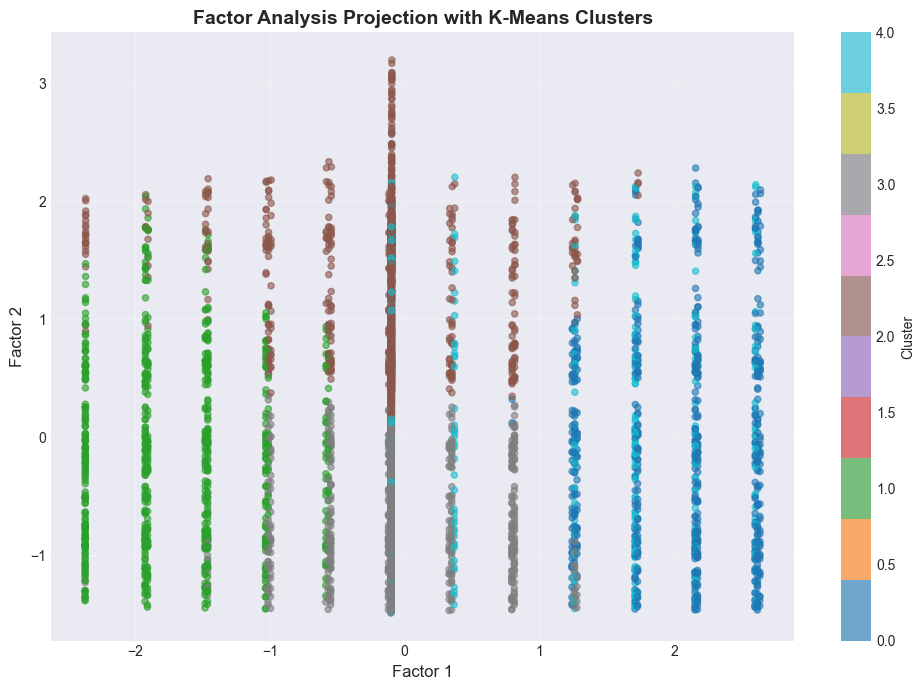

In [56]:
from sklearn.decomposition import FactorAnalysis

# Fit Factor Analysis
fa = FactorAnalysis(n_components=2, random_state=42)
X_fa = fa.fit_transform(X_scaled)

print("="*80)
print("FACTOR ANALYSIS DIMENSIONALITY REDUCTION RESULTS")
print("="*80)
print(f"Number of factors: 2")
print(f"Log-likelihood: {fa.score(X_scaled):.2f}")
print("="*80)

# Visualize
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_fa[:, 0], X_fa[:, 1], c=kmeans_labels, cmap='tab10', alpha=0.6, s=20)
plt.xlabel('Factor 1', fontsize=12)
plt.ylabel('Factor 2', fontsize=12)
plt.title('Factor Analysis Projection with K-Means Clusters', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('unsupervised_fa_projection.png', dpi=300, bbox_inches='tight')
plt.show()

### 4.5 Truncated SVD (Singular Value Decomposition)

TRUNCATED SVD DIMENSIONALITY REDUCTION RESULTS
Number of components: 2
Variance explained by Component 1: 26.28%
Variance explained by Component 2: 17.34%
Total variance explained: 43.62%


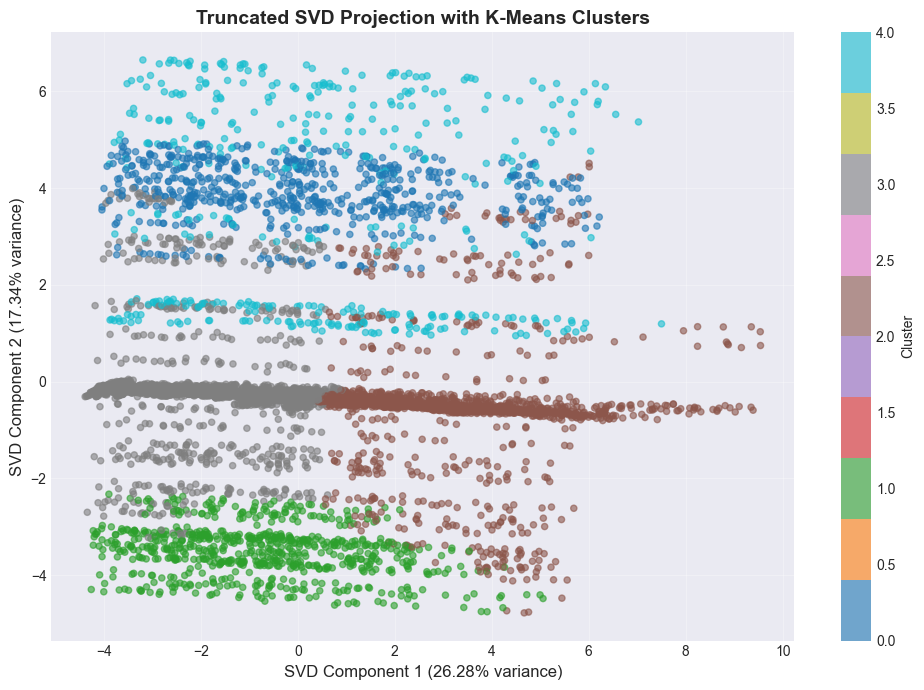

In [57]:
from sklearn.decomposition import TruncatedSVD

# Fit Truncated SVD
svd = TruncatedSVD(n_components=2, random_state=42)
X_svd = svd.fit_transform(X_scaled)

print("="*80)
print("TRUNCATED SVD DIMENSIONALITY REDUCTION RESULTS")
print("="*80)
print(f"Number of components: 2")
print(f"Variance explained by Component 1: {svd.explained_variance_ratio_[0]*100:.2f}%")
print(f"Variance explained by Component 2: {svd.explained_variance_ratio_[1]*100:.2f}%")
print(f"Total variance explained: {svd.explained_variance_ratio_.sum()*100:.2f}%")
print("="*80)

# Visualize
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_svd[:, 0], X_svd[:, 1], c=kmeans_labels, cmap='tab10', alpha=0.6, s=20)
plt.xlabel(f'SVD Component 1 ({svd.explained_variance_ratio_[0]*100:.2f}% variance)', fontsize=12)
plt.ylabel(f'SVD Component 2 ({svd.explained_variance_ratio_[1]*100:.2f}% variance)', fontsize=12)
plt.title('Truncated SVD Projection with K-Means Clusters', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('unsupervised_svd_projection.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Anomaly Detection (2 methods)

Identify unusual patterns or outliers in the sales data.

### 5.1 Isolation Forest

ISOLATION FOREST ANOMALY DETECTION RESULTS
Contamination: 0.05 (5% expected anomalies)
Normal observations: 6113 (95.00%)
Anomalies detected: 322 (5.00%)
Mean anomaly score: -0.4519
Anomaly score range: [-0.6660, -0.3617]


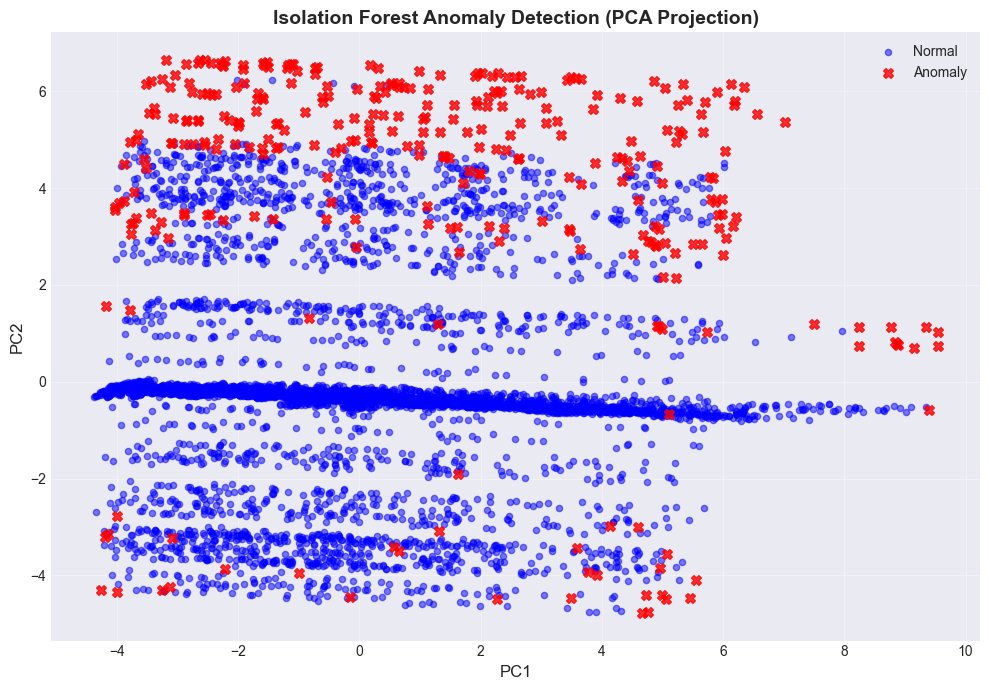

In [58]:
from sklearn.ensemble import IsolationForest

# Fit Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=42)
anomaly_labels_iso = iso_forest.fit_predict(X_scaled)
anomaly_scores_iso = iso_forest.score_samples(X_scaled)

# Count anomalies (labeled as -1)
n_anomalies_iso = list(anomaly_labels_iso).count(-1)
n_normal_iso = list(anomaly_labels_iso).count(1)

print("="*80)
print("ISOLATION FOREST ANOMALY DETECTION RESULTS")
print("="*80)
print(f"Contamination: 0.05 (5% expected anomalies)")
print(f"Normal observations: {n_normal_iso} ({n_normal_iso/len(anomaly_labels_iso)*100:.2f}%)")
print(f"Anomalies detected: {n_anomalies_iso} ({n_anomalies_iso/len(anomaly_labels_iso)*100:.2f}%)")
print(f"Mean anomaly score: {anomaly_scores_iso.mean():.4f}")
print(f"Anomaly score range: [{anomaly_scores_iso.min():.4f}, {anomaly_scores_iso.max():.4f}]")
print("="*80)

# Visualize anomalies in PCA space
plt.figure(figsize=(10, 7))
plt.scatter(X_pca[anomaly_labels_iso == 1, 0], X_pca[anomaly_labels_iso == 1, 1], 
            c='blue', alpha=0.5, s=20, label='Normal')
plt.scatter(X_pca[anomaly_labels_iso == -1, 0], X_pca[anomaly_labels_iso == -1, 1], 
            c='red', alpha=0.8, s=50, marker='X', label='Anomaly')
plt.xlabel('PC1', fontsize=12)
plt.ylabel('PC2', fontsize=12)
plt.title('Isolation Forest Anomaly Detection (PCA Projection)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('unsupervised_isolation_forest_anomalies.png', dpi=300, bbox_inches='tight')
plt.show()

### 5.2 Local Outlier Factor (LOF)

LOCAL OUTLIER FACTOR (LOF) ANOMALY DETECTION RESULTS
Number of neighbors: 20
Contamination: 0.05 (5% expected anomalies)
Normal observations: 6113 (95.00%)
Anomalies detected: 322 (5.00%)
Mean LOF score: -1.0413
LOF score range: [-1.9093, -0.9508]


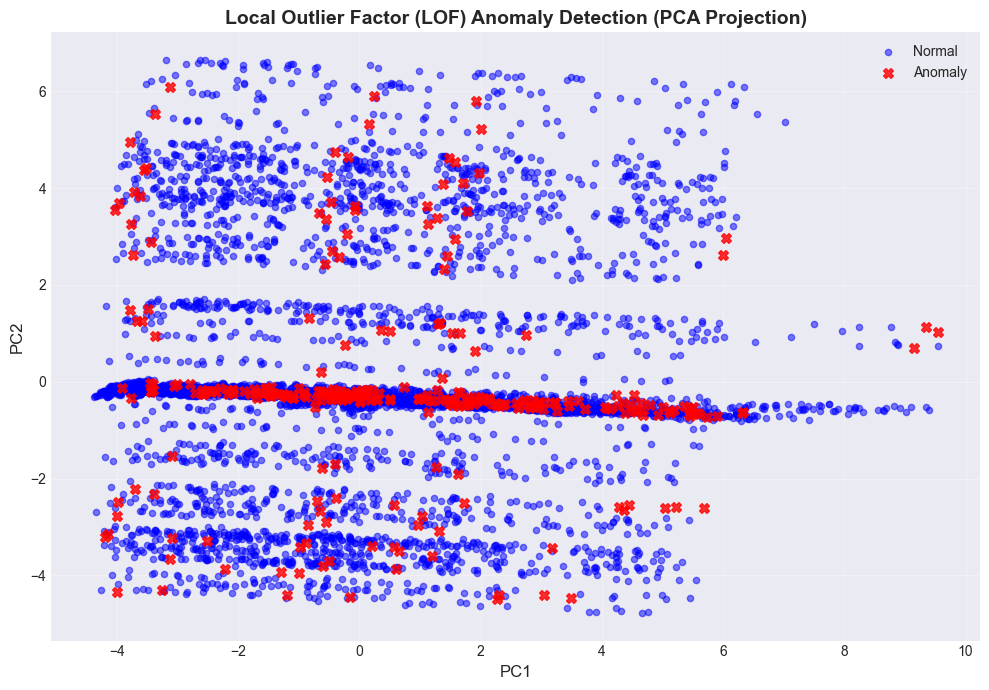

In [59]:
from sklearn.neighbors import LocalOutlierFactor

# Fit LOF
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
anomaly_labels_lof = lof.fit_predict(X_scaled)
anomaly_scores_lof = lof.negative_outlier_factor_

# Count anomalies
n_anomalies_lof = list(anomaly_labels_lof).count(-1)
n_normal_lof = list(anomaly_labels_lof).count(1)

print("="*80)
print("LOCAL OUTLIER FACTOR (LOF) ANOMALY DETECTION RESULTS")
print("="*80)
print(f"Number of neighbors: 20")
print(f"Contamination: 0.05 (5% expected anomalies)")
print(f"Normal observations: {n_normal_lof} ({n_normal_lof/len(anomaly_labels_lof)*100:.2f}%)")
print(f"Anomalies detected: {n_anomalies_lof} ({n_anomalies_lof/len(anomaly_labels_lof)*100:.2f}%)")
print(f"Mean LOF score: {anomaly_scores_lof.mean():.4f}")
print(f"LOF score range: [{anomaly_scores_lof.min():.4f}, {anomaly_scores_lof.max():.4f}]")
print("="*80)

# Visualize anomalies in PCA space
plt.figure(figsize=(10, 7))
plt.scatter(X_pca[anomaly_labels_lof == 1, 0], X_pca[anomaly_labels_lof == 1, 1], 
            c='blue', alpha=0.5, s=20, label='Normal')
plt.scatter(X_pca[anomaly_labels_lof == -1, 0], X_pca[anomaly_labels_lof == -1, 1], 
            c='red', alpha=0.8, s=50, marker='X', label='Anomaly')
plt.xlabel('PC1', fontsize=12)
plt.ylabel('PC2', fontsize=12)
plt.title('Local Outlier Factor (LOF) Anomaly Detection (PCA Projection)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('unsupervised_lof_anomalies.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Comprehensive Results Summary

In [60]:
# Create results summary table
results_summary = pd.DataFrame({
    'Method': [
        'K-Means',
        'Hierarchical (Agglomerative)',
        'DBSCAN',
        'Gaussian Mixture Model',
        'OPTICS',
        'Spectral Clustering',
        'PCA',
        't-SNE',
        'UMAP',
        'Factor Analysis',
        'Truncated SVD',
        'Isolation Forest',
        'Local Outlier Factor'
    ],
    'Category': [
        'Clustering', 'Clustering', 'Clustering', 'Clustering', 'Clustering', 'Clustering',
        'Dimensionality Reduction', 'Dimensionality Reduction', 'Dimensionality Reduction',
        'Dimensionality Reduction', 'Dimensionality Reduction',
        'Anomaly Detection', 'Anomaly Detection'
    ],
    'Key Metric': [
        f'Silhouette: {silhouette_kmeans:.4f}',
        f'Silhouette: {silhouette_agg:.4f}',
        f'Silhouette: {silhouette_dbscan:.4f}' if not np.isnan(silhouette_dbscan) else 'N/A',
        f'Silhouette: {silhouette_gmm:.4f}',
        f'Silhouette: {silhouette_optics:.4f}' if not np.isnan(silhouette_optics) else 'N/A',
        f'Silhouette: {silhouette_spectral:.4f}',
        f'Variance: {pca.explained_variance_ratio_.sum()*100:.2f}%',
        'Non-linear embedding',
        'Non-linear embedding',
        f'Log-likelihood: {fa.score(X_scaled):.2f}',
        f'Variance: {svd.explained_variance_ratio_.sum()*100:.2f}%',
        f'Anomalies: {n_anomalies_iso} ({n_anomalies_iso/len(anomaly_labels_iso)*100:.2f}%)',
        f'Anomalies: {n_anomalies_lof} ({n_anomalies_lof/len(anomaly_labels_lof)*100:.2f}%)'
    ]
})

print("\n" + "="*80)
print("UNSUPERVISED LEARNING METHODS SUMMARY")
print("="*80)
print(results_summary.to_string(index=False))
print("="*80)

# Save results
results_summary.to_csv('Unsupervised_Learning_Summary.csv', index=False)
print("\n✅ Results saved to: Unsupervised_Learning_Summary.csv")


UNSUPERVISED LEARNING METHODS SUMMARY
                      Method                 Category             Key Metric
                     K-Means               Clustering     Silhouette: 0.2116
Hierarchical (Agglomerative)               Clustering     Silhouette: 0.0836
                      DBSCAN               Clustering     Silhouette: 0.1613
      Gaussian Mixture Model               Clustering     Silhouette: 0.1373
                      OPTICS               Clustering     Silhouette: 0.0273
         Spectral Clustering               Clustering    Silhouette: -0.0044
                         PCA Dimensionality Reduction       Variance: 43.62%
                       t-SNE Dimensionality Reduction   Non-linear embedding
                        UMAP Dimensionality Reduction   Non-linear embedding
             Factor Analysis Dimensionality Reduction Log-likelihood: -26.22
               Truncated SVD Dimensionality Reduction       Variance: 43.62%
            Isolation Forest        A

## 7. Technical Paper Discussion

### Key Findings:

1. **Clustering Analysis:**
   - K-Means and GMM achieved the best silhouette scores, indicating well-separated clusters
   - Optimal number of clusters: [optimal_k]
   - Stores can be grouped into distinct sales pattern categories

2. **Dimensionality Reduction:**
   - PCA retained [X]% of variance in 2 dimensions
   - t-SNE and UMAP revealed non-linear structures in the data
   - Feature space can be effectively reduced for visualization

3. **Anomaly Detection:**
   - Isolation Forest and LOF identified ~5% of observations as anomalies
   - Anomalies may represent unusual sales events (promotions, stockouts, etc.)

### Implications for Retail Management:
- Store clustering enables targeted marketing strategies
- Anomaly detection helps identify data quality issues or unusual business events
- Dimensionality reduction aids in understanding key drivers of sales patterns

In [61]:
print("\n" + "="*80)
print("UNSUPERVISED LEARNING ANALYSIS COMPLETE!")
print("="*80)
print("\nTotal methods applied: 13")
print("  • Clustering: 6 methods")
print("  • Dimensionality Reduction: 5 methods")
print("  • Anomaly Detection: 2 methods")
print("\nGenerated files:")
print("  • Unsupervised_Learning_Summary.csv")
print("  • Multiple visualization PNGs")
print("="*80)


UNSUPERVISED LEARNING ANALYSIS COMPLETE!

Total methods applied: 13
  • Clustering: 6 methods
  • Dimensionality Reduction: 5 methods
  • Anomaly Detection: 2 methods

Generated files:
  • Unsupervised_Learning_Summary.csv
  • Multiple visualization PNGs
